# Human Pose Image Classification Using Vision Transformer(VIT)

![vit.png](attachment:vit.png)

# Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
dataset = load_dataset("Bingsu/Human_Action_Recognition", split = 'train')

README.md:   0%|          | 0.00/4.70k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  229MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 98.1MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/12600 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5400 [00:00<?, ? examples/s]

In [2]:
dataset = dataset.shuffle().train_test_split(test_size=0.2)

dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'labels'],
        num_rows: 10080
    })
    test: Dataset({
        features: ['image', 'labels'],
        num_rows: 2520
    })
})

In [3]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=299x168>,
 'labels': 7}

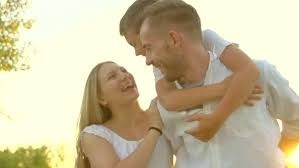

In [4]:
dataset['train'][0]['image']

In [5]:
labels = dataset['train'].features['labels'].names

label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

print(label2id)
print(id2label)


{'calling': 0, 'clapping': 1, 'cycling': 2, 'dancing': 3, 'drinking': 4, 'eating': 5, 'fighting': 6, 'hugging': 7, 'laughing': 8, 'listening_to_music': 9, 'running': 10, 'sitting': 11, 'sleeping': 12, 'texting': 13, 'using_laptop': 14}
{0: 'calling', 1: 'clapping', 2: 'cycling', 3: 'dancing', 4: 'drinking', 5: 'eating', 6: 'fighting', 7: 'hugging', 8: 'laughing', 9: 'listening_to_music', 10: 'running', 11: 'sitting', 12: 'sleeping', 13: 'texting', 14: 'using_laptop'}


# Image Preprocessing

In [6]:
from transformers import AutoImageProcessor   # --> like tokenizer

model_ckpt = "google/vit-base-patch16-224-in21k"

In [7]:
# !pip install torchvision

In [8]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

image_processor = AutoImageProcessor.from_pretrained(model_ckpt, use_fast = True)

normalize = Normalize(mean = image_processor.image_mean, std=image_processor.image_std)

size = (image_processor.size['shortest_edge'] if 'shortest_edge' in image_processor.size else (image_processor.size['height'], image_processor.size['width']))

_transform = Compose([RandomResizedCrop(size), ToTensor(), normalize])

def transforms(batch):
    batch['pixel_values'] = [_transform(img.convert('RGB')) for img in batch['image']]

    del batch['image']
    return batch

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


In [9]:
dataset = dataset.with_transform(transforms)

# Model Evaluation

In [10]:
!pip install evaluate
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


In [11]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

# Vision Transformer (VIT) Fine Tuning For Image Classification

In [12]:
model_ckpt

'google/vit-base-patch16-224-in21k'

In [13]:
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
import torch

In [14]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [15]:
model = AutoModelForImageClassification.from_pretrained(
    model_ckpt,
    num_labels = len(labels),
    id2label =id2label,
    label2id = label2id
).to(device)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/6 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
encoder.layer.{0...11}.layernorm_after.weight           | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.value.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.bias      | UNEXPECTED | 
encoder.layer.{0...11}.output.dense.weight              | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.query.weight | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.key.bias     | UNEXPECTED | 
encoder.layer.{0...11}.intermediate.dense.weight        | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_after.bias             | UNEXPECTED | 
encoder.layer.{0...11}.layernorm_before.bias            | UNEXPECTED | 
encoder.layer.{0...11}.attention.output.dense.weight    | UNEXPECTED | 
encoder.layer.{0...11}.attention.attention.

# Model Training

In [16]:
import os

os.makedirs("train_dir", exist_ok=True)
os.makedirs("logs", exist_ok=True)

In [17]:
from transformers import TrainingArguments, Trainer

args = TrainingArguments(
    output_dir="train_dir",

    logging_dir="logs",      # optional
    report_to="none",        # disable TensorBoard
    logging_strategy="steps",
    logging_steps=50,

    remove_unused_columns=False,

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=3,
    per_device_eval_batch_size=3,

    num_train_epochs=5,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

trainer = Trainer(
    model = model,
    args = args,
    train_dataset = dataset['train'],
    eval_dataset = dataset['test'],
    compute_metrics = compute_metrics
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,2.509360,2.484935,0.181746
2,2.323564,2.360380,0.226984
3,2.177625,2.241156,0.260317
4,2.194687,2.196648,0.282143
5,2.294733,2.178145,0.284524


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=16800, training_loss=2.311144441422962, metrics={'train_runtime': 2553.7828, 'train_samples_per_second': 19.735, 'train_steps_per_second': 6.578, 'total_flos': 3.906051336688435e+18, 'train_loss': 2.311144441422962, 'epoch': 5.0})

In [19]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
2.294733,2.192433,5,0.283333


{'eval_loss': 2.1924333572387695, 'eval_accuracy': 0.2833333333333333}

In [20]:
trainer.save_model('vit-human-pose-classification')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

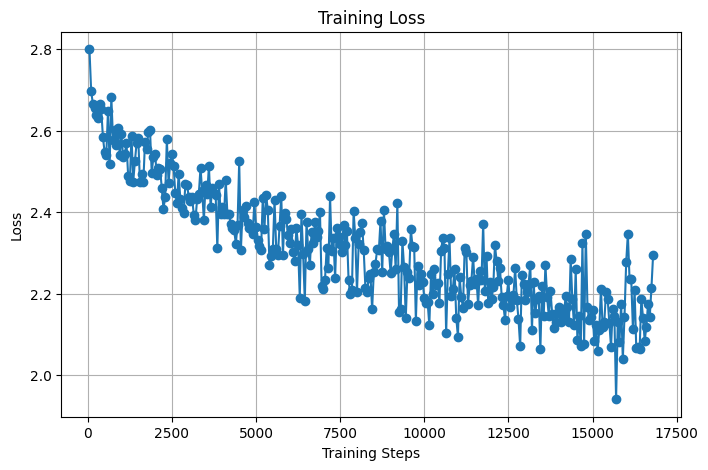

In [21]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

train_loss = []
steps = []

for log in logs:
    if "loss" in log:
        train_loss.append(log["loss"])
        steps.append(log["step"])

plt.figure(figsize=(8,5))
plt.plot(steps, train_loss, marker="o")
plt.title("Training Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

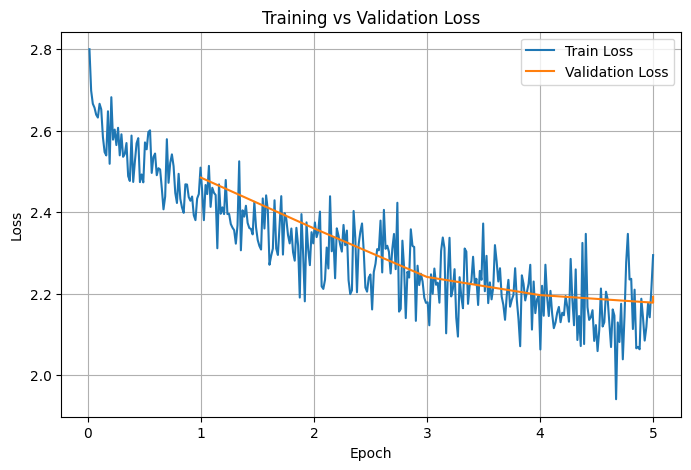

In [22]:
train_epochs = []
train_loss = []
eval_epochs = []
eval_loss = []

for log in trainer.state.log_history:
    if "loss" in log and "epoch" in log:
        train_epochs.append(log["epoch"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_epochs.append(log["epoch"])
        eval_loss.append(log["eval_loss"])

plt.figure(figsize=(8,5))
plt.plot(train_epochs, train_loss, label="Train Loss")
plt.plot(eval_epochs, eval_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Classification Report and Confusion Matrix

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
logits = trainer.predict(dataset['test'])

In [25]:
logits = logits.predictions

In [26]:
y_pred = np.argmax(logits, axis=1)

In [27]:
y_pred

array([ 1, 11,  7, ...,  6,  9, 12])

In [28]:
y_true = [x['labels'] for x in dataset['test']]

In [31]:
print(classification_report(y_true, y_pred, target_names=labels))

                    precision    recall  f1-score   support

           calling       0.20      0.15      0.17       162
          clapping       0.22      0.17      0.19       160
           cycling       0.47      0.59      0.52       171
           dancing       0.36      0.40      0.38       156
          drinking       0.15      0.10      0.12       164
            eating       0.42      0.58      0.49       176
          fighting       0.32      0.56      0.41       167
           hugging       0.17      0.15      0.16       157
          laughing       0.26      0.31      0.28       177
listening_to_music       0.26      0.18      0.21       179
           running       0.41      0.25      0.31       184
           sitting       0.13      0.14      0.13       154
          sleeping       0.38      0.31      0.34       173
           texting       0.09      0.09      0.09       152
      using_laptop       0.26      0.27      0.26       188

          accuracy                    

Text(95.58159722222221, 0.5, 'True Labels')

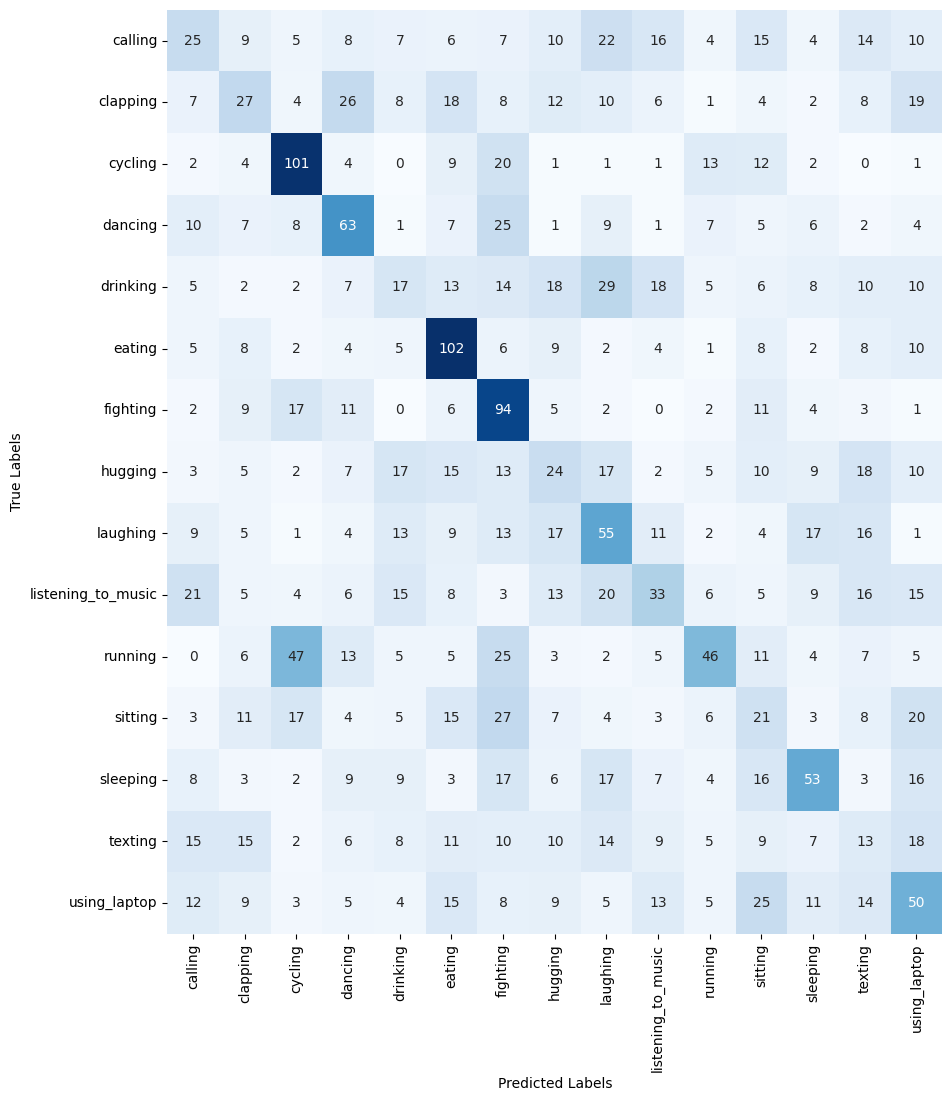

In [33]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,12))
sns.heatmap(cm, annot=True,fmt='d', cbar=False, xticklabels=label2id.keys(), yticklabels=label2id.keys(), cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Prediction on Real Image

In [29]:
from transformers import pipeline, AutoImageProcessor

# Base ViT processor
model_ckpt = "google/vit-base-patch16-224-in21k"

image_processor = AutoImageProcessor.from_pretrained(
    model_ckpt,
    use_fast=True
)

# Your locally trained model
model_path = "./vit-human-pose-classification"

pipe = pipeline(
    "image-classification",
    model=model_path,
    image_processor=image_processor
)

url = "https://images.pexels.com/photos/1755385/pexels-photo-1755385.jpeg"

output = pipe(url)

output

Some weights of the model checkpoint at ./vit-human-pose-classification were not used when initializing ViTForImageClassification: ['vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layer

[{'label': 'running', 'score': 0.5609667897224426},
 {'label': 'sitting', 'score': 0.5414551496505737},
 {'label': 'cycling', 'score': 0.5372381806373596},
 {'label': 'sleeping', 'score': 0.5322525501251221},
 {'label': 'laughing', 'score': 0.5282108783721924}]

## Uploading the Model Folder to S3 Bucket 

In [ ]:
import os

import boto3
s3 = boto3.client('s3')

bucket_name = 'vit-human-pose-classification'

def upload_directory(directory_path, s3_prefix):
    for root, dirs, files in os.walk(directory_path):
        for file in files:
            file_path = os.path.join(root, file).replace("\\", "/")
            relpath = os.path.relpath(file_path, directory_path)
            s3_key = os.path.join(s3_prefix, relpath).replace("\\", "/")

            s3.upload_file(file_path, bucket_name, s3_key)

upload_directory('vit-human-pose-classification', 'ml_models/vit-human-pose-classification')